In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc file CSV (Bạn thay tên file tương ứng nhé)
df = pd.read_csv("C:\Data\Customer Purchasing Behaviors.csv")

# Xem 5 dòng đầu tiên
print(df.head())

<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Admin\AppData\Local\Temp\ipykernel_3212\3234126006.py:6: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("C:\Data\Customer Purchasing Behaviors.csv")


   user_id  age  annual_income  purchase_amount  loyalty_score region  \
0        1   25          45000              200            4.5  North   
1        2   34          55000              350            7.0  South   
2        3   45          65000              500            8.0   West   
3        4   22          30000              150            3.0   East   
4        5   29          47000              220            4.8  North   

   purchase_frequency  
0                  12  
1                  18  
2                  22  
3                  10  
4                  13  


In [3]:
#Thống kê mô tả
print(df[['age', 'annual_income', 'purchase_amount', 'loyalty_score']].describe())

              age  annual_income  purchase_amount  loyalty_score
count  238.000000     238.000000       238.000000     238.000000
mean    38.676471   57407.563025       425.630252       6.794118
std      9.351118   11403.875717       140.052062       1.899047
min     22.000000   30000.000000       150.000000       3.000000
25%     31.000000   50000.000000       320.000000       5.500000
50%     39.000000   59000.000000       440.000000       7.000000
75%     46.750000   66750.000000       527.500000       8.275000
max     55.000000   75000.000000       640.000000       9.500000


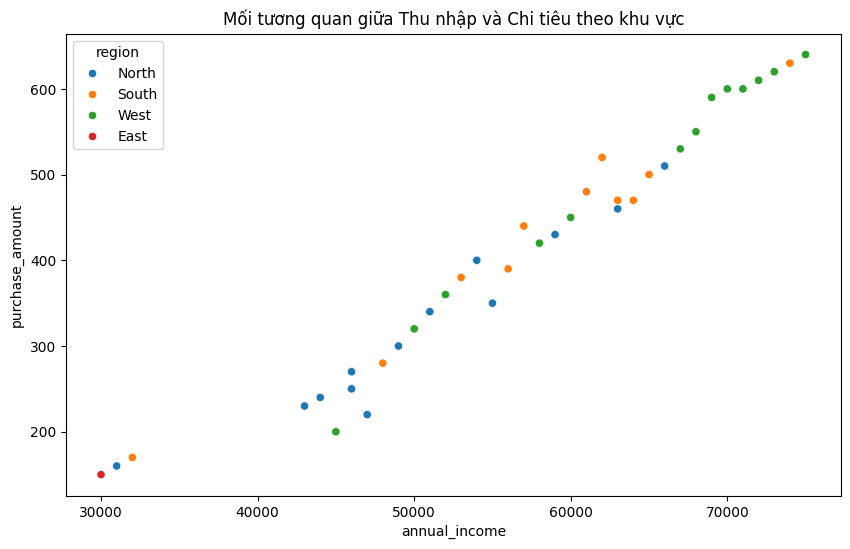

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='annual_income', y='purchase_amount', hue='region')
plt.title('Mối tương quan giữa Thu nhập và Chi tiêu theo khu vực')
plt.show()


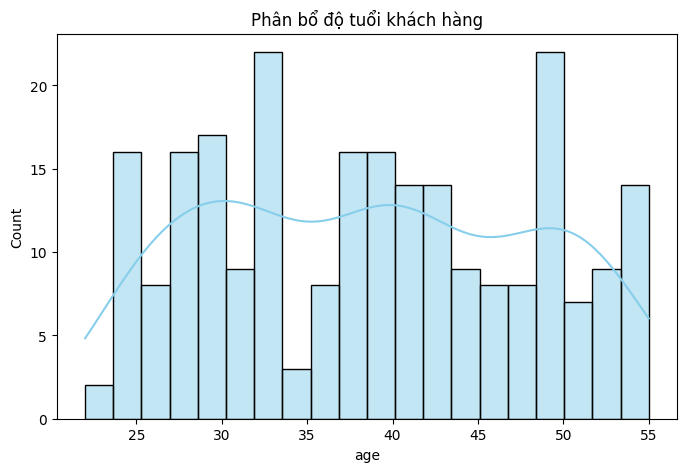

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Phân bổ độ tuổi khách hàng')
plt.show()

In [13]:
from pandasql import sqldf
import sqlite3
pysqldf = lambda q: sqldf(q, globals())
conn = sqlite3.connect(r"C:\Data\Customer Purchasing Behaviors.csv")
query = """
SELECT 
    CASE 
        WHEN age < 30 THEN 'Dưới 30'
        WHEN age BETWEEN 30 AND 50 THEN '31 - 50'
        ELSE 'Trên 50'
    END AS Age_Group,
    AVG(annual_income) AS Avg_Income,
    AVG(purchase_amount) AS Avg_Spending
FROM df
GROUP BY Age_Group
ORDER BY Avg_Spending DESC;
"""

df_result = pysqldf(query)
print(df_result)

  Age_Group    Avg_Income  Avg_Spending
0   Trên 50  72966.666667    619.666667
1   31 - 50  59828.025478    455.541401
2   Dưới 30  40803.921569    219.411765


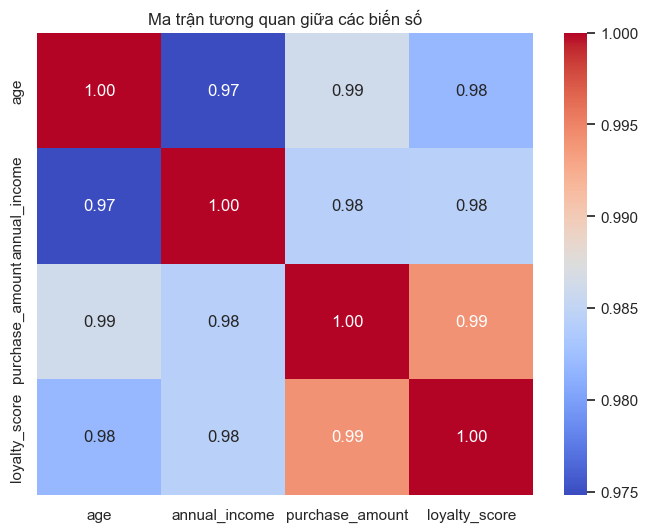

In [33]:
corr_matrix = df[['age', 'annual_income', 'purchase_amount', 'loyalty_score']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_3212\2128696200.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_result, x='Age_Group', y='Avg_Spending', palette='viridis')


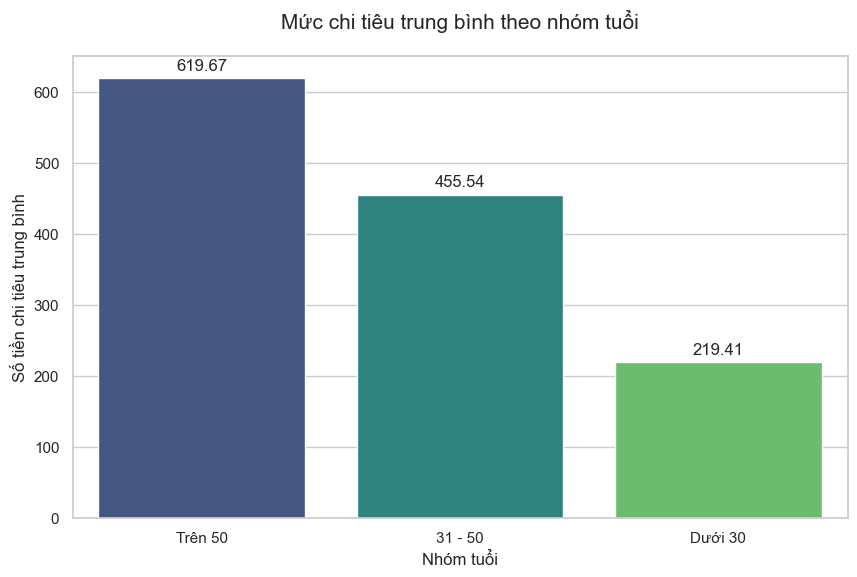

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách cho biểu đồ
sns.set_theme(style="whitegrid")

# Khởi tạo khung hình
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_result, x='Age_Group', y='Avg_Spending', palette='viridis')
plt.title('Mức chi tiêu trung bình theo nhóm tuổi', fontsize=15, pad=20)
plt.xlabel('Nhóm tuổi', fontsize=12)
plt.ylabel('Số tiền chi tiêu trung bình', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

In [26]:
pysqldf = lambda q: sqldf(q, globals())
conn = sqlite3.connect(r'C:\Data\olist_ecommerce.db')
query_segment = """
SELECT 
    user_id,
    age,
    region,  -- BẮT BUỘC phải thêm dòng này để bảng mới có cột region
    CASE 
        WHEN age < 30 THEN 'Gen Z'
        WHEN age BETWEEN 30 AND 45 THEN 'Millennials'
        ELSE 'Gen X+'
    END AS Age_Segment,
    
    CASE 
        WHEN loyalty_score >= 8 THEN 'VIP'
        WHEN loyalty_score BETWEEN 5 AND 7.9 THEN 'Tiềm năng'
        ELSE 'Cần chăm sóc'
    END AS Loyalty_Rank,
    
    purchase_amount,
    loyalty_score
FROM df; -- df là bảng gốc của bạn
"""

df_segmented = pysqldf(query_segment)

print(df_segmented.head())

   user_id  age region  Age_Segment  Loyalty_Rank  purchase_amount  \
0        1   25  North        Gen Z  Cần chăm sóc              200   
1        2   34  South  Millennials     Tiềm năng              350   
2        3   45   West  Millennials           VIP              500   
3        4   22   East        Gen Z  Cần chăm sóc              150   
4        5   29  North        Gen Z  Cần chăm sóc              220   

   loyalty_score  
0            4.5  
1            7.0  
2            8.0  
3            3.0  
4            4.8  


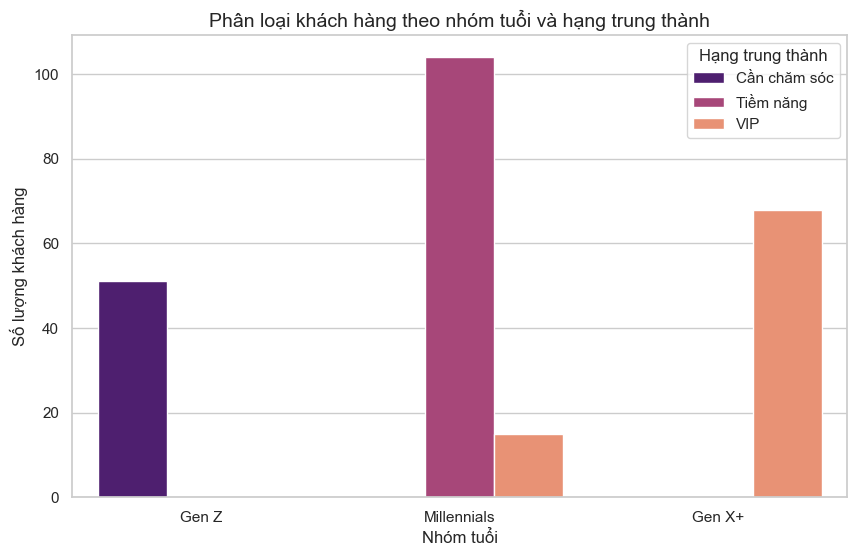

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ biểu đồ phân bổ khách hàng theo Hạng trung thành (Loyalty_Rank)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_segmented, x='Age_Segment', hue='Loyalty_Rank', palette='magma')

plt.title('Phân loại khách hàng theo nhóm tuổi và hạng trung thành', fontsize=14)
plt.xlabel('Nhóm tuổi')
plt.ylabel('Số lượng khách hàng')
plt.legend(title='Hạng trung thành')
plt.show()

In [27]:
pysqldf = lambda q: sqldf(q, globals())
conn = sqlite3.connect(r'C:\Data\olist_ecommerce.db')
query_having = """
SELECT 
    region,
    Age_Segment,
    COUNT(user_id) AS Total_Customers,
    AVG(purchase_amount) AS Avg_Spending,
    AVG(loyalty_score) AS Avg_Loyalty
FROM df_segmented
GROUP BY region, Age_Segment
HAVING Avg_Spending > 400 AND Avg_Loyalty > 7
ORDER BY Avg_Spending DESC;
"""

df_analysis = pysqldf(query_having)
print("Các nhóm khách hàng mục tiêu cao cấp:")
print(df_analysis)

Các nhóm khách hàng mục tiêu cao cấp:
  region  Age_Segment  Total_Customers  Avg_Spending  Avg_Loyalty
0  South       Gen X+                9    628.888889     9.388889
1   West       Gen X+               43    597.209302     9.004651
2  North       Gen X+               16    551.875000     8.518750
3  South  Millennials               54    443.518519     7.146296


In [28]:
conn = sqlite3.connect(r'C:\Data\olist_ecommerce.db')
query_cte = """
WITH Segmented_Data AS (
    SELECT 
        user_id,
        region,
        purchase_amount,
        CASE 
            WHEN age < 30 THEN 'Gen Z'
            WHEN age BETWEEN 30 AND 45 THEN 'Millennials'
            ELSE 'Gen X+'
        END AS Age_Segment,
        CASE 
            WHEN loyalty_score >= 8 THEN 'VIP'
            WHEN loyalty_score BETWEEN 5 AND 7.9 THEN 'Tiềm năng'
            ELSE 'Cần chăm sóc'
        END AS Loyalty_Rank
    FROM df
)
SELECT 
    Age_Segment,
    Loyalty_Rank,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(purchase_amount), 2) AS Avg_Spending
FROM Segmented_Data
GROUP BY Age_Segment, Loyalty_Rank
HAVING Total_Customers > 5
ORDER BY Age_Segment, Avg_Spending DESC;
"""

df_final = pysqldf(query_cte)
print(df_final)

   Age_Segment  Loyalty_Rank  Total_Customers  Avg_Spending
0       Gen X+           VIP               68        590.74
1        Gen Z  Cần chăm sóc               51        219.41
2  Millennials           VIP               15        509.33
3  Millennials     Tiềm năng              104        406.73


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




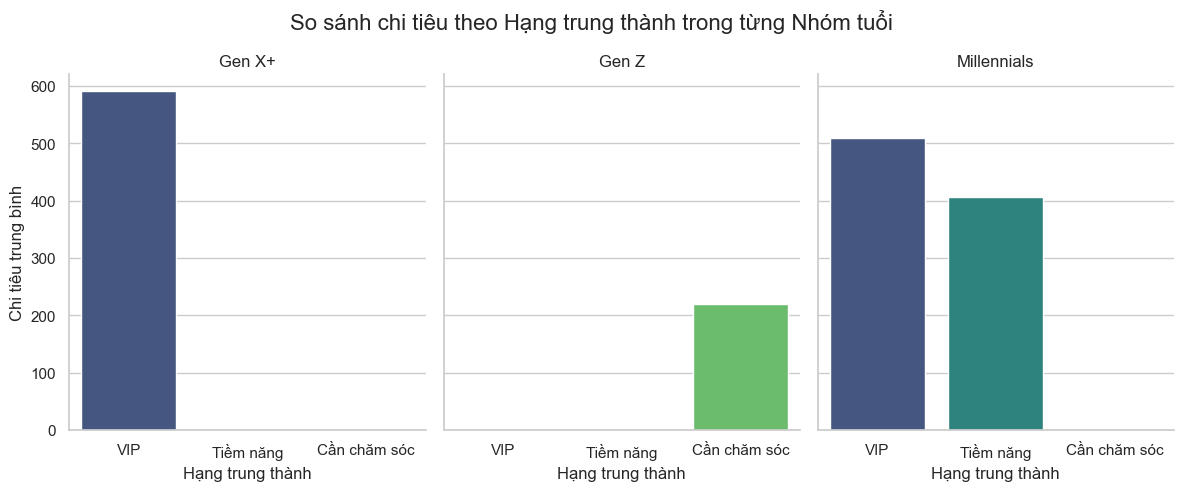

In [29]:
g = sns.FacetGrid(df_final, col="Age_Segment", height=5, aspect=0.8)
g.map(sns.barplot, "Loyalty_Rank", "Avg_Spending", palette="viridis", order=["VIP", "Tiềm năng", "Cần chăm sóc"])

g.set_axis_labels("Hạng trung thành", "Chi tiêu trung bình")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('So sánh chi tiêu theo Hạng trung thành trong từng Nhóm tuổi', fontsize=16)

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_3212\1363290317.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




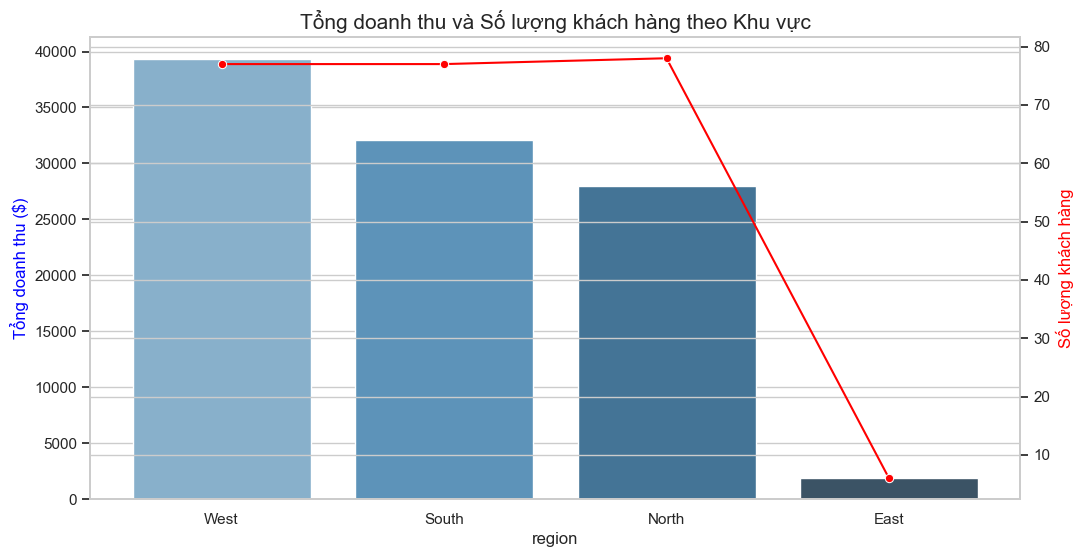

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán dữ liệu theo khu vực
region_analysis = df_segmented.groupby('region').agg(
    total_customers=('user_id', 'count'),
    total_revenue=('purchase_amount', 'sum'),
    avg_spending=('purchase_amount', 'mean')
).reset_index().sort_values(by='total_revenue', ascending=False)

# 2. Vẽ biểu đồ
plt.figure(figsize=(12, 6))

# Vẽ cột cho doanh thu (Revenue)
ax1 = sns.barplot(data=region_analysis, x='region', y='total_revenue', palette='Blues_d')
ax1.set_ylabel('Tổng doanh thu ($)', fontsize=12, color='blue')
ax1.set_title('Tổng doanh thu và Số lượng khách hàng theo Khu vực', fontsize=15)

# Vẽ đường cho số lượng khách hàng (Customer count) trên cùng một biểu đồ
ax2 = ax1.twinx()
sns.lineplot(data=region_analysis, x='region', y='total_customers', color='red', marker='o', ax=ax2)
ax2.set_ylabel('Số lượng khách hàng', fontsize=12, color='red')

plt.show()

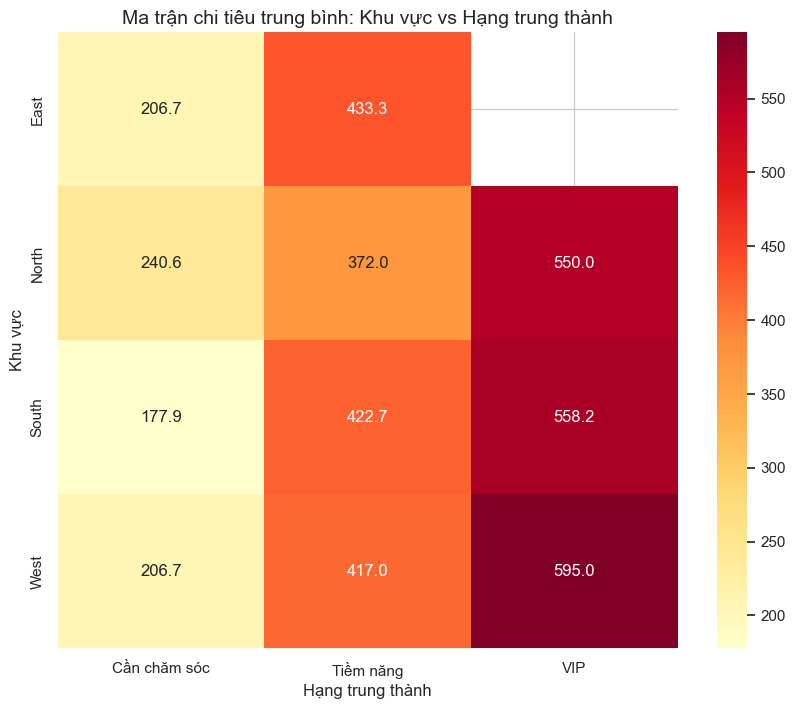

In [32]:
# Tạo bảng Pivot: Khu vực vs Hạng trung thành (tính chi tiêu trung bình)
region_loyalty_pivot = df_segmented.pivot_table(
    index='region', 
    columns='Loyalty_Rank', 
    values='purchase_amount', 
    aggfunc='mean'
)

plt.figure(figsize=(10, 8))
sns.heatmap(region_loyalty_pivot, annot=True, fmt=".1f", cmap="YlOrRd")

plt.title('Ma trận chi tiêu trung bình: Khu vực vs Hạng trung thành', fontsize=14)
plt.xlabel('Hạng trung thành')
plt.ylabel('Khu vực')
plt.show()

In [34]:
query_at_risk = """
SELECT 
    user_id, age, region, annual_income, purchase_amount, loyalty_score
FROM df
WHERE annual_income > (SELECT AVG(annual_income) FROM df) -- Thu nhập trên trung bình
AND purchase_amount < (SELECT AVG(purchase_amount) FROM df) -- Nhưng chi tiêu dưới trung bình
ORDER BY annual_income DESC;
"""
df_at_risk = pysqldf(query_at_risk)
print("Danh sách khách hàng thu nhập cao nhưng chi tiêu ít (Cần giữ chân):")
print(df_at_risk.head())

Danh sách khách hàng thu nhập cao nhưng chi tiêu ít (Cần giữ chân):
   user_id  age region  annual_income  purchase_amount  loyalty_score
0       14   37   East          58000              420            6.8
1       42   37   West          58000              420            6.8
2       72   37   West          58000              420            6.8
3      102   37   West          58000              420            6.8
4      132   37   West          58000              420            6.8


C:\Users\Admin\AppData\Local\Temp\ipykernel_3212\4012684487.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




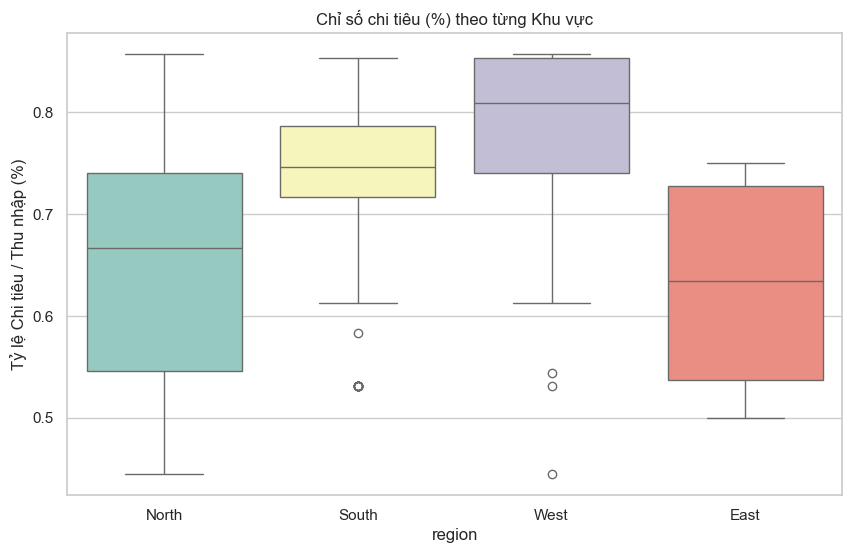

In [36]:
df['spending_ratio'] = (df['purchase_amount'] / df['annual_income']) * 100

# Trực quan hóa theo khu vực
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='region', y='spending_ratio', palette='Set3')
plt.title('Chỉ số chi tiêu (%) theo từng Khu vực')
plt.ylabel('Tỷ lệ Chi tiêu / Thu nhập (%)')
plt.show()

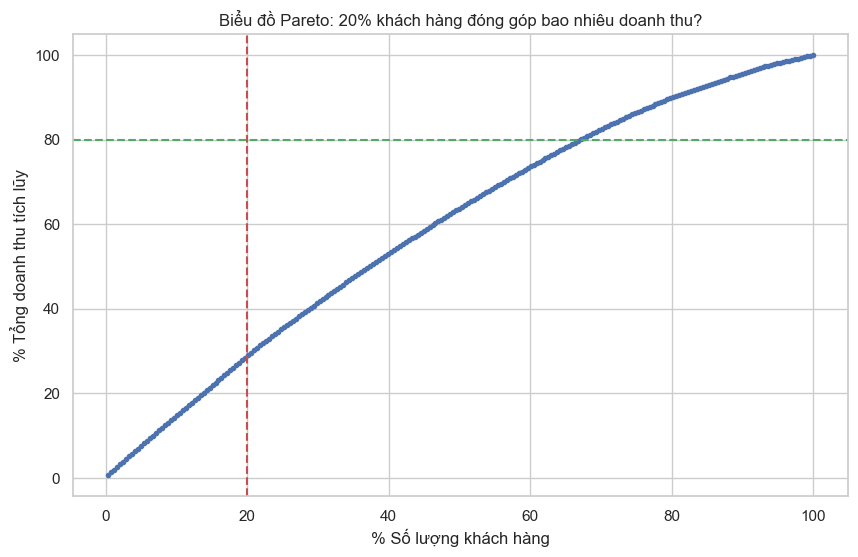

In [38]:
import numpy as np
df_sorted = df.sort_values(by='purchase_amount', ascending=False)
total_revenue = df_sorted['purchase_amount'].sum()

# Tính % đóng góp tích lũy
df_sorted['cumulative_revenue_pct'] = df_sorted['purchase_amount'].cumsum() / total_revenue * 100
df_sorted['customer_pct'] = (np.arange(len(df_sorted)) + 1) / len(df_sorted) * 100

# Vẽ biểu đồ Pareto
plt.figure(figsize=(10, 6))
plt.plot(df_sorted['customer_pct'], df_sorted['cumulative_revenue_pct'], marker='.')
plt.axvline(20, color='r', linestyle='--')
plt.axhline(80, color='g', linestyle='--')
plt.title('Biểu đồ Pareto: 20% khách hàng đóng góp bao nhiêu doanh thu?')
plt.xlabel('% Số lượng khách hàng')
plt.ylabel('% Tổng doanh thu tích lũy')
plt.grid(True)
plt.show()